# ENSF 444 Final Project: Customer Churn Prediction
### Group #: 21  
### Client: Auracole
### Name(s): Sahil B and Jibran S


The purpose of this project is to develop a machine learning pipeline to predict customer churn for Auracole. We compare three different models (Logistic Regression, Random Forest, and XGBoost) using a workflow that includes preprocessing, dimensionality reduction, and evaluation via ROC AUC.

Link to dataset: https://www.kaggle.com/competitions/playground-series-s6e3/overview

### Step 0: Import Libraries

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Validation Metrics
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

import warnings
warnings.filterwarnings('ignore')

### Step 1: Load Data
Load the training and testing datasets from the Kaggle Playground Series.

In [49]:
# Load datasets
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Define target and features
target = 'Churn'
X = train_df.drop(columns=[target, 'id'])
y = train_df[target]

X_test_final = test_df.drop(columns=['id'])

print(f"Training data shape: {X.shape}")
X.head()

Training data shape: (594194, 19)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45


See distribution of the classes

In [50]:
#TODO: get count and percentages of target variable/classes in one table
class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True)

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages)



Class Counts:
Churn
No     460377
Yes    133817
Name: count, dtype: int64

Class Percentages:
Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64


Visualizing the datasest

note: check out downsampling and up sampling before training the models

imblearn

1.   List item
2.   List item



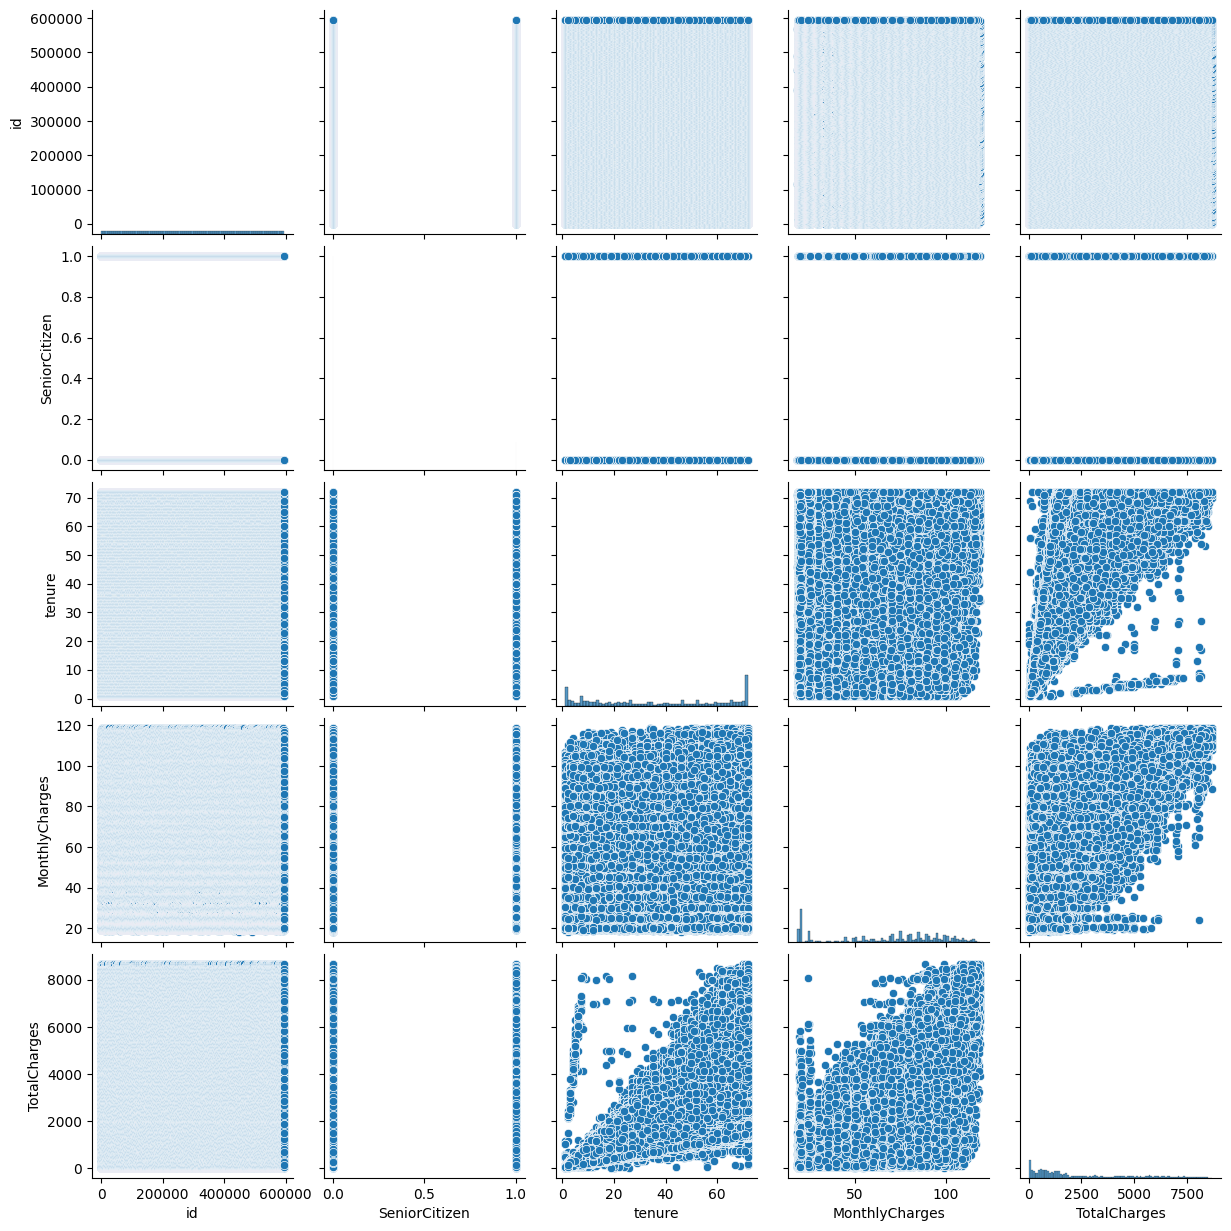

In [51]:
# Pairplot

sns.pairplot(train_df)
plt.show()

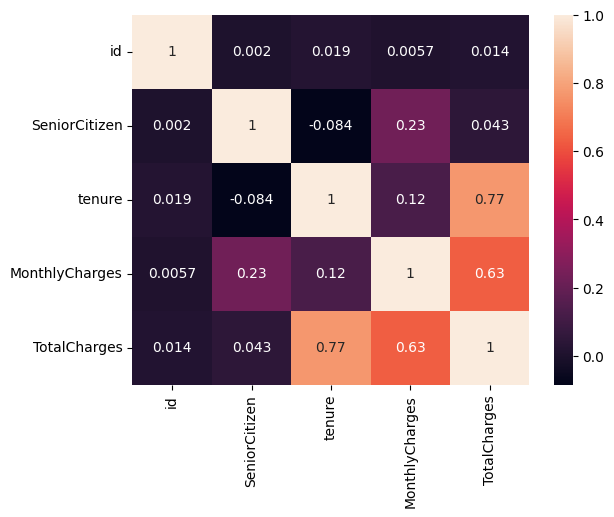

In [52]:
# Correalation plot

sns.heatmap(train_df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

### Step 2: Data Processing


Check to see if there are missing date in the dataset

In [53]:
X_missing = X.isna().sum().sum()
y_missing = y.isna().sum().sum()


print(f"Num missing in X: {X_missing}")
print(f"Num missing in y: {y_missing}")

Num missing in X: 0
Num missing in y: 0


In this step, we implement the preprocessing steps proposed: Standard Scaling for numerical data, One-Hot Encoding for categorical data, and PCA for dimensionality reduction.

In [54]:
# Identify feature types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Define transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features)
    ])

# Drop rows where 'Churn' (y) is NaN before splitting
# This is necessary because train_test_split with stratify=y cannot handle NaN in y
non_nan_indices = y.dropna().index
X_cleaned = X.loc[non_nan_indices]
y_cleaned = y.loc[non_nan_indices]

# Convert 'No' and 'Yes' to 0 and 1 for the target variable
y_cleaned = y_cleaned.map({'No': 0, 'Yes': 1})

# Split for validation
X_train, X_val, y_train, y_val = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42, stratify=y_cleaned)

PCA compenents

In [55]:
#TODO: check how many pca components the data would get reduced to at n_components=0.95
pca = PCA(n_components=0.95)

# do the preprocessor before passing in X_train
X_train_transformed = preprocessor.fit_transform(X_train)
pca.fit(X_train_transformed)

print(f"NUmber of features in regular dataset: {len(X_train.columns)}")
print(f"Number of PCA components: {pca.n_components_}")



NUmber of features in regular dataset: 19
Number of PCA components: 17


### Step 3: ML Model Implementation
We initialize our three models: Logistic Regression (Baseline), Random Forest, and XGBoost.

In [56]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, device='cuda')
}

results = {}

### Step 3.1: Hyperparameter Tuning

In [57]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grids for each model
# Using small grids for demonstration; for production, larger grids might be needed.
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.1, 1.0, 10.0]
    },
    'Random Forest': {
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [10, 20]
    },
    'XGBoost': {
        'classifier__n_estimators': [50, 100],
        'classifier__learning_rate': [0.05, 0.1]
    }
}

In [58]:
for name, model in models.items():
    print(f"Processing {name}...")

    # Create a base pipeline up to the classifier
    base_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.95)),
        ('classifier', model)
    ])

    if name in param_grids:
        print(f"  Performing Grid Search for {name}...")
        # Use GridSearchCV to find the best hyperparameters
        grid_search = GridSearchCV(base_pipeline, param_grids[name], cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
        grid_search.fit(X_train, y_train)

        best_pipeline = grid_search.best_estimator_
        y_pred_proba = best_pipeline.predict_proba(X_val)[:, 1]

        # Score the best estimator
        auc = roc_auc_score(y_val, y_pred_proba)
        fpr, tpr, _ = roc_curve(y_val, y_pred_proba)

        results[name] = {'auc': auc, 'fpr': fpr, 'tpr': tpr, 'pipeline': best_pipeline, 'best_params': grid_search.best_params_}
        print(f"  {name} Best Params: {grid_search.best_params_}")
        print(f"  {name} ROC AUC (tuned): {auc:.4f}")
    else:
        # Fit and Predict for models not undergoing Grid Search
        base_pipeline.fit(X_train, y_train)
        y_pred_proba = base_pipeline.predict_proba(X_val)[:, 1]

        # Score the model
        auc = roc_auc_score(y_val, y_pred_proba)
        fpr, tpr, _ = roc_curve(y_val, y_pred_proba)

        results[name] = {'auc': auc, 'fpr': fpr, 'tpr': tpr, 'pipeline': base_pipeline}
        print(f"  {name} ROC AUC: {auc:.4f}")

Processing Logistic Regression...
  Performing Grid Search for Logistic Regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
  Logistic Regression Best Params: {'classifier__C': 0.1}
  Logistic Regression ROC AUC (tuned): 0.9057
Processing Random Forest...
  Performing Grid Search for Random Forest...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
  Random Forest Best Params: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}
  Random Forest ROC AUC (tuned): 0.9089
Processing XGBoost...
  Performing Grid Search for XGBoost...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
  XGBoost Best Params: {'classifier__learning_rate': 0.1, 'classifier__n_estimators': 100}
  XGBoost ROC AUC (tuned): 0.9107


### Step 4: Validation and Metrics
We train each model using a Pipeline and evaluate the performance using the Area Under the ROC Curve (AUC).

In [59]:
for name, model in models.items():
    # Create full pipeline with PCA
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.95)),
        ('classifier', model)
    ])

    # Fit and Predict
    clf.fit(X_train, y_train)
    y_pred_proba = clf.predict_proba(X_val)[:, 1]

    # Score
    auc = roc_auc_score(y_val, y_pred_proba)
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)

    results[name] = {'auc': auc, 'fpr': fpr, 'tpr': tpr, 'pipeline': clf}
    print(f"{name} ROC AUC: {auc:.4f}")

Logistic Regression ROC AUC: 0.9057
Random Forest ROC AUC: 0.8856
XGBoost ROC AUC: 0.9097


### Step 5: Visualization of Results
Visualize the performance comparison using ROC Curves.

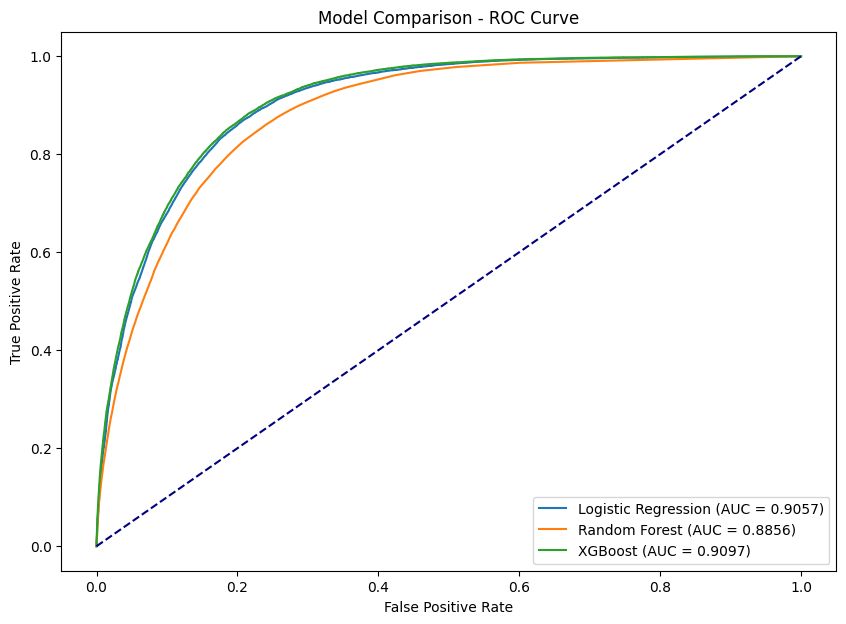

In [60]:
plt.figure(figsize=(10, 7))
for name, m in results.items():
    plt.plot(m['fpr'], m['tpr'], label=f"{name} (AUC = {m['auc']:.4f})")

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model Comparison - ROC Curve')
plt.legend(loc="lower right")
plt.show()

### Step 5.1: Confusion Matrix Visualization

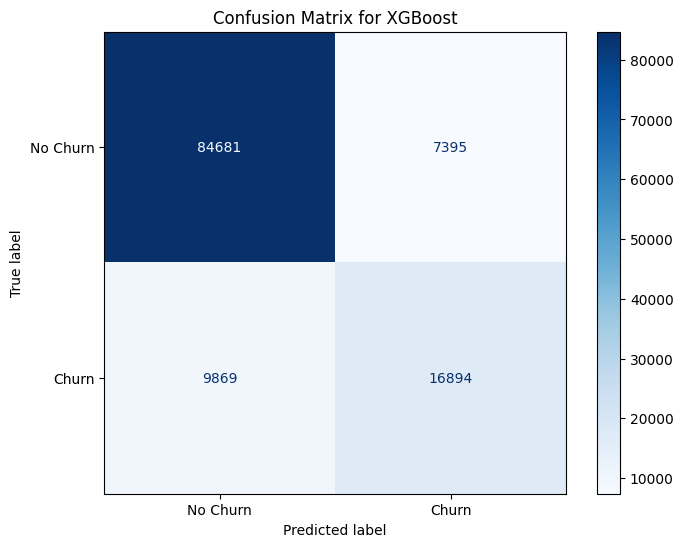

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the best model pipeline (after tuning, if applicable)
best_model_name_for_cm = max(results, key=lambda k: results[k]['auc'])
best_pipeline_for_cm = results[best_model_name_for_cm]['pipeline']

# Predict classes for the validation set
y_pred_val = best_pipeline_for_cm.predict(X_val)

# Generate confusion matrix
cm = confusion_matrix(y_val, y_pred_val, labels=[0, 1])

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Confusion Matrix for {best_model_name_for_cm}')
plt.grid(False) # Turn off grid for confusion matrix
plt.show()

### Step 6: Final Submission
Generate the submission file for Kaggle using the best performing model.

In [62]:
best_model_name = max(results, key=lambda k: results[k]['auc'])
best_pipeline = results[best_model_name]['pipeline']

final_predictions = best_pipeline.predict_proba(X_test_final)[:, 1]

submission = pd.DataFrame({
    'id': test_df['id'],
    'Churn': final_predictions
})

submission.to_csv('submission.csv', index=False)
print(f"Submission created using {best_model_name}.")

Submission created using XGBoost.
